## Context
This dataset was downloaded from: https://www.kaggle.com/datasets/pasindugeevinda/game-telemetry-and-player-archetype-modeling-aura?resource=download
It contains anonymized player telemetry data extracted from "AURA", a custom 3D third-person video game. The data were collected to model and classify different "Player Archetypes" based on in-game behavior, specifically measuring Combat, Collection, and Exploration playstyles over active gameplay sessions.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
import json
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

### Data loading and merging

In [36]:
# Define the path to the dataset
WORKING_DIR = '/home/santiagodp/Documents/ML/AURA_players-analysis/'
DATASET_DIR = os.path.join(WORKING_DIR, 'Raw_Data')
MODELS_DIR = os.path.join(WORKING_DIR, 'models')
VIZ_DIR = os.path.join(WORKING_DIR, 'visualizations')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# Define the timestep of the telemetry, which tracks 30-second windows of playtime.
timestep = 30

# Open the telemetry data
telemetry_file = DATASET_DIR + '/telemetry_phase_2.telemetries.csv'
deathevents_file = DATASET_DIR + '/telemetry_phase_2.deathevents.csv'

In [37]:
# A video game generates events asynchronously. 
# A player actions (like shooting) and deaths are stored in different tables.
print("Loading raw data...")
df_telemetry = pd.read_csv(telemetry_file)
df_deaths = pd.read_csv(deathevents_file)

print(f"\nTelemetry shape: {df_telemetry.shape}")
print(f"\nDeaths shape: {df_deaths.shape}")

print(f"\nTelemetry columns and data:")
print(df_telemetry.columns.tolist())
df_telemetry.info()

Loading raw data...

Telemetry shape: (4691, 30)

Deaths shape: (324, 7)

Telemetry columns and data:
['_id', 'userId', 'timestamp', 'sessionId', 'itemsCollected', 'pickupAttempts', 'timeNearInteractables', 'enemiesHit', 'damageDone', 'timeInCombat', 'distanceTraveled', 'timeOutOfCombat', 'timeSprinting', 'kills', 'died', 'rawJson.user_id', 'rawJson.session_id', 'rawJson.timestamp', 'rawJson.items_collected', 'rawJson.pickup_attempts', 'rawJson.time_near_interactables', 'rawJson.enemies_hit', 'rawJson.damage_done', 'rawJson.time_in_combat', 'rawJson.distance_traveled', 'rawJson.time_out_of_combat', 'rawJson.time_sprinting', 'rawJson.kills', 'rawJson.deaths', '__v']
<class 'pandas.DataFrame'>
RangeIndex: 4691 entries, 0 to 4690
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   _id                              4691 non-null   str    
 1   userId                           4691 n

In [38]:
# The timestamps are stored as strings in ISO8601 format. 
# We need to convert them to datetime objects for analysis.
df_telemetry['timestamp'] = pd.to_datetime(df_telemetry['timestamp'], format='ISO8601', errors='coerce')
df_deaths['timestamp'] = pd.to_datetime(df_deaths['timestamp'], format='ISO8601', errors='coerce')

# Dropping rows with invalid timestamps, if any
df_telemetry = df_telemetry.dropna(subset=['timestamp'])
df_deaths = df_deaths.dropna(subset=['timestamp'])

# Convert the timestamps to Unix time (seconds since epoch)
df_telemetry['timestamp'] = df_telemetry['timestamp'].apply(lambda x: x.timestamp())
df_deaths['timestamp'] = df_deaths['timestamp'].apply(lambda x: x.timestamp())

# Normalize timestamps by subtracting the minimum value for better numerical stability
t0 = min(df_telemetry['timestamp'].min(), df_deaths['timestamp'].min())
df_telemetry['timestamp'] = df_telemetry['timestamp'] - t0
df_deaths['timestamp'] = df_deaths['timestamp'] - t0

# Initialize a column to count deaths in each telemetry window
df_telemetry['death_count'] = 0

# Sorting for time-based logic
df_telemetry.sort_values(by=['userId', 'timestamp'], inplace=True)
df_deaths.sort_values(by=['userId', 'timestamp'], inplace=True)

# show the first few rows
df_telemetry.head(10)

,_id,userId,timestamp,sessionId,itemsCollected,pickupAttempts,timeNearInteractables,enemiesHit,damageDone,timeInCombat,...,rawJson.enemies_hit,rawJson.damage_done,rawJson.time_in_combat,rawJson.distance_traveled,rawJson.time_out_of_combat,rawJson.time_sprinting,rawJson.kills,rawJson.deaths,__v,death_count
3643,69778ccf32e87512c91665c6,69747994eb8c4eacdf21a48d,197507.489,unreal_1769442511102,0,0,0,8,130.666667,8.5,...,8,130.666667,8.5,10855.920406,21.5,17.0,1,0,0,0
3675,6977913814d93dd960a5e134,69747994eb8c4eacdf21a48d,198636.679,unreal_1769443640292,1,1,1,0,0.000000,0.0,...,0,0.000000,0.0,4406.146249,7.5,7.5,0,0,0,0
3676,6977914514d93dd960a5e1cf,69747994eb8c4eacdf21a48d,198649.643,unreal_1769443653256,1,3,10,0,0.000000,0.0,...,0,0.000000,0.0,2612.056669,10.5,4.5,0,0,0,0
3678,6977915414d93dd960a5e26a,69747994eb8c4eacdf21a48d,198665.146,unreal_1769443668759,1,2,1,1,18.666667,2.5,...,1,18.666667,2.5,3198.798340,7.5,4.5,0,0,0,0
3700,697793e70bd58997e878973f,69747994eb8c4eacdf21a48d,199323.718,unreal_1769444327331,1,1,1,0,0.000000,0.0,...,0,0.000000,0.0,4577.154536,7.5,7.5,0,0,0,0
3702,697793f10bd58997e87897da,69747994eb8c4eacdf21a48d,199333.731,unreal_1769444337344,1,1,0,0,0.000000,0.0,...,0,0.000000,0.0,5742.237236,10.5,10.5,0,0,0,0
3704,697794160bd58997e878988c,69747994eb8c4eacdf21a48d,199371.231,unreal_1769444374844,3,3,3,0,0.000000,0.0,...,0,0.000000,0.0,4660.481447,8.0,8.0,0,0,0,0
3706,697794240bd58997e8789927,69747994eb8c4eacdf21a48d,199384.910,unreal_1769444388523,1,1,2,0,0.000000,0.0,...,0,0.000000,0.0,4351.848125,9.5,5.5,0,0,0,0
3707,6977942e0bd58997e87899c2,69747994eb8c4eacdf21a48d,199394.927,unreal_1769444398540,0,0,0,7,98.666667,8.5,...,7,98.666667,8.5,1322.649637,2.0,0.5,0,0,0,0
3708,6977943b0bd58997e8789a63,69747994eb8c4eacdf21a48d,199407.619,unreal_1769444411232,0,0,0,9,77.333333,6.0,...,9,77.333333,6.0,249.309730,3.5,0.0,2,0,0,0


In [39]:
# Player actions and deaths are stored in different tables. We need to merge the deathevents 
# to the corresponding 30-second window of the telemetry file. 

print("Mapping consecutive deaths...")
count_mapped = 0
telemetry_grouped = df_telemetry.groupby('userId')

# Contextual Mapping Loop
for user_id, user_deaths in df_deaths.groupby('userId'):
    if user_id in telemetry_grouped.groups:
        user_tele_indices = telemetry_grouped.groups[user_id]
        user_tele_times = df_telemetry.loc[user_tele_indices, 'timestamp'].values

        for death_time in user_deaths['timestamp']:
            if pd.isna(death_time): continue
            
            # Match telemetry window (Death_time <= Tick < Death_time + 30s)
            mask = (death_time <= user_tele_times) & (user_tele_times < death_time + timestep)
            matched = np.where(mask)[0]

            if len(matched) > 0:
                match_idx = user_tele_indices[matched[0]]
                df_telemetry.at[match_idx, 'death_count'] += 1
                count_mapped += 1

print(f"Successfully mapped {count_mapped} death events to telemetry windows.")
df = df_telemetry.copy()
# Note: this mapping can be done differently to keep the time order, but I will keep it like this 
# to follow the original structure of the notebook.
# Also, it might be optimal to use t0 = user_tele['timestamp'].iloc[0], and then 
# idx = int(round((death_time - t0) / 30)), exploiting the fact that the telemetry is sampled every 
# 30 seconds and that the data has already been ordered.

Mapping consecutive deaths...
Successfully mapped 39 death events to telemetry windows.


In [40]:
# Total number of unique users
unique_users = df['userId'].unique()

# Number of users with at least one invalid timeOutOfCombat (> 31)
invalid_users = df[df['timeOutOfCombat'] > 31]['userId'].nunique()

print(f"Total users: {len(unique_users)}")
print(f"Users with invalid timeOutOfCombat (> 30s): {invalid_users}")
#--> I confirmed that it was the first user that was problematic using the plot below for unique_user[0]

Total users: 68
Users with invalid timeOutOfCombat (> 30s): 1


### Gameplay Summary & Trimming
We limit the analysis according to the duration of the session: Players that played too little are not useful, and players that played too much generate too much data and are weighted too much. 

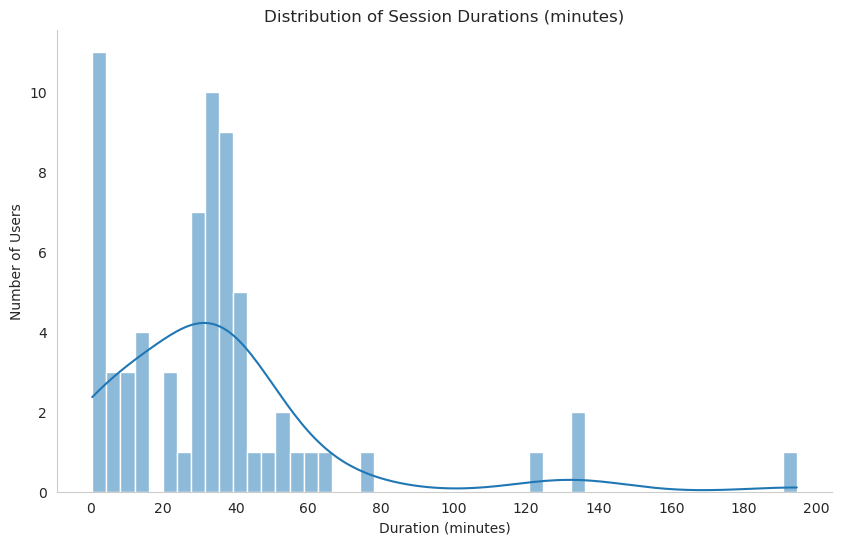

In [41]:
# To decide the duration, we first plot a histogram of the session durations. We compute the total
# duration for each user by counting the number of rows and multiplying by 30 seconds. Then we 
# convert that to minutes for easier interpretation.
user_stats = df.groupby('userId').size().reset_index(name='total_rows')
user_stats['duration_min'] = (user_stats['total_rows'] * timestep) / 60

# Plot the distribution of session durations
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(user_stats['duration_min'], bins=50, kde=True)
plt.title('Distribution of Session Durations (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Users')

# Set ticks explicitly
sns.despine()
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_minor_locator(MultipleLocator(5))

plt.grid()
plt.savefig(os.path.join(VIZ_DIR, 'session_duration_distribution.png'))
plt.show()

In [42]:
# Based on the histogram, we will remove a population of users that played less than 20 minutes. 
# For the tail of users that played more than 60 minutes, we cap their data at 60 minutes to
# not overtrain with them.
min_duration = 19
cap_duration = 60
valid_users = user_stats[user_stats['duration_min'] >= min_duration]
print(f"Keeping {len(valid_users)} valid users (>= {min_duration} mins). Dropping {len(user_stats) - len(valid_users)}.")

# Also remove users with any invalid timeOutOfCombat (> 31)
invalid_users = df[df['timeOutOfCombat'] > 31]['userId'].unique()
valid_users = valid_users[~valid_users['userId'].isin(invalid_users)]
print(f"Keeping {len(valid_users)} valid users after filtering for invalid times out of combat")

df = df[df['userId'].isin(valid_users['userId'])].copy()
user_stats = df.groupby('userId').size().reset_index(name='total_rows')
user_stats['duration_min'] = (user_stats['total_rows'] * 30) / 60

# Sort & Cap (note that the time order might have been changed by the mapping)
df['sort_helper'] = pd.to_numeric(df['timestamp'], errors='coerce')
df.sort_values(by=['userId', 'sort_helper'], inplace=True)
df.drop(columns=['sort_helper'], inplace=True)

max_rows = int((cap_duration * 60) / 30) # 90 rows
df = df.groupby('userId').head(max_rows).copy()

print(f"Trimmed dataset down to {len(df)} discrete evaluation windows.")

Keeping 47 valid users (>= 19 mins). Dropping 21.
Keeping 46 valid users after filtering for invalid times out of combat
Trimmed dataset down to 3579 discrete evaluation windows.


Analyzing User 697591b7547a2b541d110069


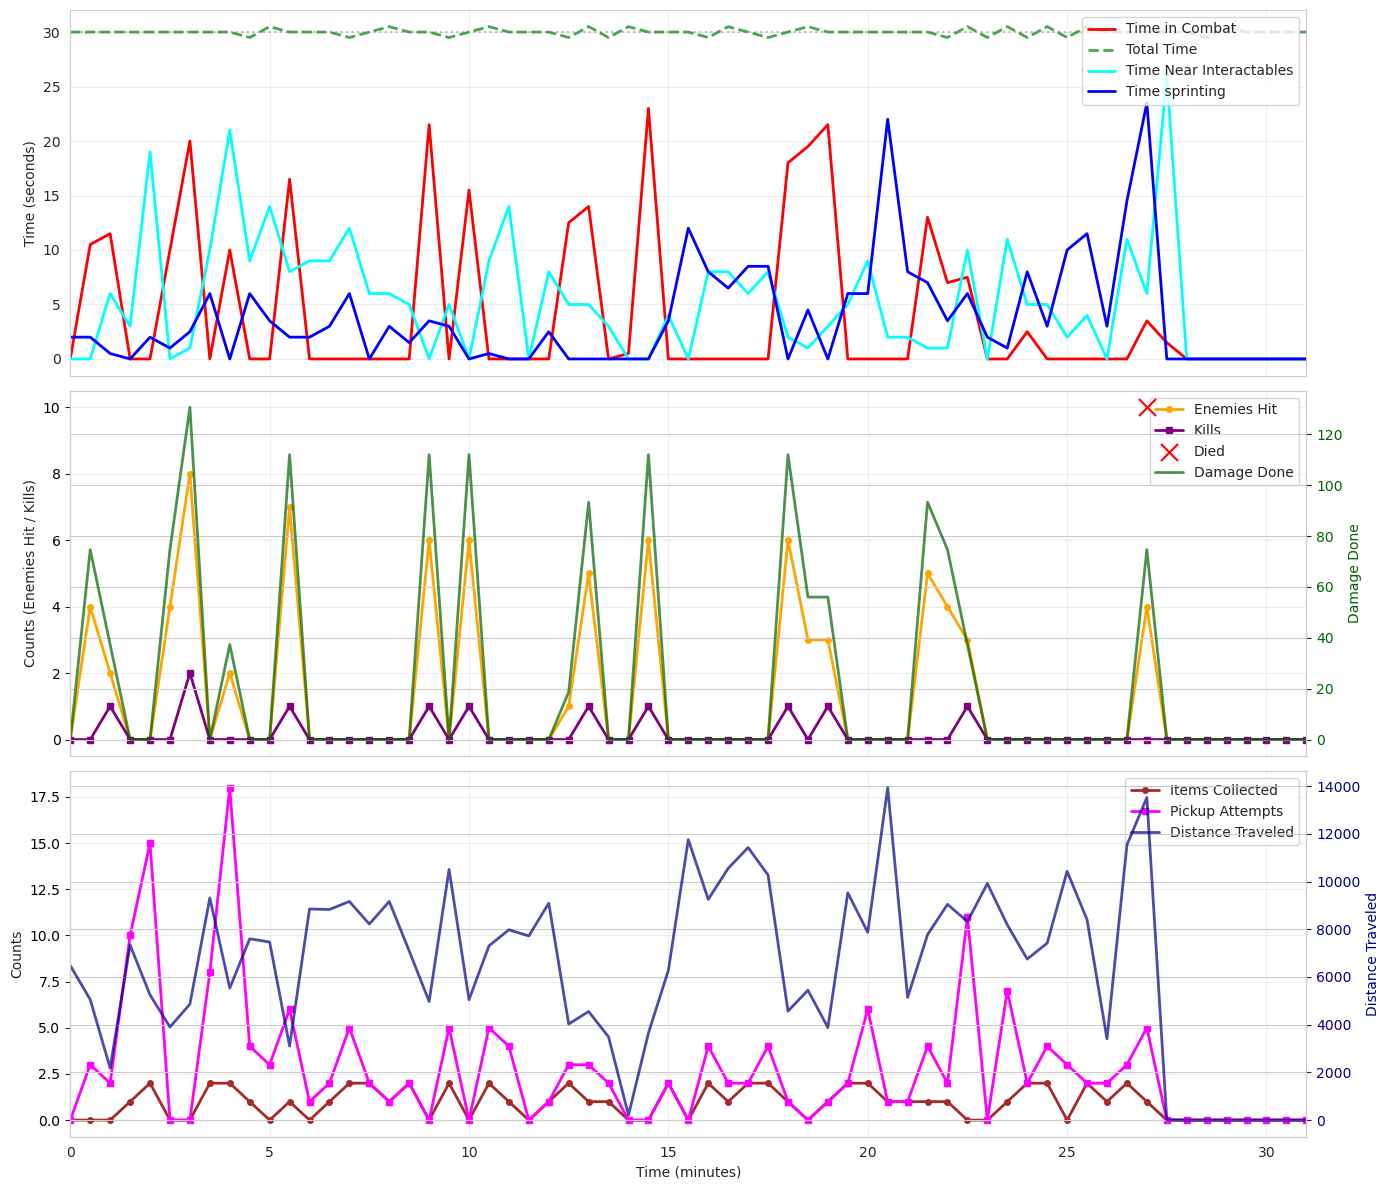

In [44]:
# Let's make a plot of a playing session in order to see what it looks like.
# The plot will have three parts:
# 1) How they spent their time
# 2) Combat-related actions
# 3) Gathering-related actions 

# Select a specific user
unique_users = df['userId'].unique()
user_id = unique_users[10]
user_data = df[df['userId'] == user_id].copy()
print(f"Analyzing User {user_id}")

# Sort by timestamp to ensure proper ordering
user_data = user_data.sort_values('timestamp')

# Create tick index, such that the time in minutes is tick * 0.5 (since each tick is 30 seconds)
user_data['tick'] = range(len(user_data))
user_data['time_minutes'] = user_data['tick'] * 0.5

# Create figure with 2 panels
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ============================================
# UPPER PANEL: Time-related quantities
# ============================================
# Calculate total time (should equal 30 seconds per tick if consistent)
user_data['total_time'] = user_data['timeInCombat'] + user_data['timeOutOfCombat']

ax1.plot(user_data['time_minutes'], user_data['timeInCombat'], 
         label='Time in Combat', linewidth=2, color='red')
#ax1.plot(user_data['time_minutes'], user_data['timeOutOfCombat'], 
#         label='Time Out of Combat', linewidth=2, color='pink')
ax1.plot(user_data['time_minutes'], user_data['total_time'], 
         label='Total Time', linewidth=2, color='green', alpha=0.7, linestyle='--')
ax1.plot(user_data['time_minutes'], user_data['timeNearInteractables'], 
         label='Time Near Interactables', linewidth=2, color='cyan')
ax1.plot(user_data['time_minutes'], user_data['timeSprinting'], 
         label='Time sprinting', linewidth=2, color='blue')

ax1.set_ylabel('Time (seconds)')
ax1.set_title(f'')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add a horizontal line at 30 seconds to verify data consistency
ax1.axhline(y=30, color='gray', linestyle=':', alpha=0.5, label='')

# ============================================
# MIDDLE PANEL: Combat Stats
# ============================================
# Plot enemiesHit and kills on primary y-axis
ax2.plot(user_data['time_minutes'], user_data['enemiesHit'], 
         label='Enemies Hit', linewidth=2, color='orange', marker='o', markersize=4)
ax2.plot(user_data['time_minutes'], user_data['kills'], 
         label='Kills', linewidth=2, color='purple', marker='s', markersize=4)

# Plot died as discrete events (where it's 1)
death_times = user_data[user_data['death_count'] == 1]['time_minutes']
if len(death_times) > 0:
    ax2.scatter(death_times, [10] * len(death_times), 
                color='red', s=150, marker='x', zorder=6, label='Died')

ax2.set_ylabel('Counts (Enemies Hit / Kills)')
ax2.tick_params(axis='y', labelcolor='black')
ax2.grid(True, alpha=0.3)

# Create secondary y-axis for damageDone
ax2_damage = ax2.twinx()
ax2_damage.plot(user_data['time_minutes'], user_data['damageDone'], 
                label='Damage Done', linewidth=2, color='darkgreen', linestyle='-', alpha=0.7)
ax2_damage.set_ylabel('Damage Done', color='darkgreen')
ax2_damage.tick_params(axis='y', labelcolor='darkgreen')

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_damage.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='best')


# ============================================
# BOTTOM PANEL: Gathering Stats
# ============================================
ax3.plot(user_data['time_minutes'], user_data['itemsCollected'], 
         label='Items Collected', linewidth=2, color='brown', marker='o', markersize=4)
ax3.plot(user_data['time_minutes'], user_data['pickupAttempts'], 
         label='Pickup Attempts', linewidth=2, color='magenta', marker='s', markersize=4)

ax3.set_xlabel('Time (minutes)')
ax3.set_ylabel('Counts')
ax3.tick_params(axis='y', labelcolor='black')
ax3.grid(True, alpha=0.3)

# Create secondary y-axis for distanceTraveled
ax3_distance = ax3.twinx()
ax3_distance.plot(user_data['time_minutes'], user_data['distanceTraveled'], 
                  label='Distance Traveled', linewidth=2, color='darkblue', linestyle='-', alpha=0.7)
ax3_distance.set_ylabel('Distance Traveled', color='darkblue')
ax3_distance.tick_params(axis='y', labelcolor='darkblue')

# Combine legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_distance.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')

# ============================================
# Format x-axis
# ============================================
ax3.set_xlabel('Time (minutes)')
ax3.set_xlim(user_data['time_minutes'].min(), user_data['time_minutes'].max())

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'example_user_behaviour.png'))
plt.show()

### Feature Engineering & Normalization
The goal is to create new, smarter metrics and put them all on a level playing field. 
We engineer new features that point to player efficiency, like damage_per_hit. We also use a MinMax Scaler so that distance, kills, etc., are normalized to the interval [0:1] in order for the Neural Network to not get confused by the scale of the features. 

In [32]:
# 1. Capture sniper/heavy-weapon players (low enemies hit, high dmg)
df['damage_per_hit'] = df['damageDone'] / df['enemiesHit'].clip(lower=1)
# --> The clip is to avoid division by zero. It might be better to set it to NaN, but 
# I will keep it like this for now to follow the original structure of the notebook, but other option is below
#df['damage_per_hit'] = ( df['damageDone'] / df['enemiesHit'].replace(0, np.nan) )
#print(f"Total of NaNs in damage_per_hit: {df['damage_per_hit'].notna().sum()}")
#print(f"Total of NaNs in damage_per_hit: {df['damage_per_hit'].isna().sum()}")
#print(f"Total of NaNs in damage_per_hit: {df['damage_per_hit'].isna().mean()}")

# 2. Capture collection intent (differentiating incidental roaming from active gathering)
df['pickup_attempt_rate'] = df['pickupAttempts'] / df['timeNearInteractables'].clip(lower=1)

features_to_normalize = [
    'enemiesHit', 'damageDone', 'timeInCombat', 'kills',
    'itemsCollected', 'pickupAttempts', 'timeNearInteractables',
    'distanceTraveled', 'timeSprinting', 'timeOutOfCombat',
    'damage_per_hit', 'pickup_attempt_rate'
]
available_features = [f for f in features_to_normalize if f in df.columns]

scaler = MinMaxScaler()
df[available_features] = scaler.fit_transform(df[available_features].fillna(0))

print("Applied strict MinMaxScaler [0, 1] normalization.")

# Export scaler config for potential external use
scaler_params = {
    'features': available_features,
    'data_min': scaler.data_min_.tolist(),
    'data_max': scaler.data_max_.tolist(),
    'data_range': (scaler.data_max_ - scaler.data_min_).tolist(),
    'min_value': float(scaler.feature_range[0]),
    'max_value': float(scaler.feature_range[1])
}
with open(os.path.join(MODELS_DIR, 'scaler_params.json'), 'w') as f:
    json.dump(scaler_params, f, indent=2)

Applied strict MinMaxScaler [0, 1] normalization.


### Activity Contributions

Compress dozens of stats into three focused 'Domain Scores'.

Instead of asking our AI to look at 12 variables simultaneously, we are going to group them. We take all the combat-related stats (damage, enemies hit, kills, time in combat) and mathematically average them into a single score_combat. We do the same for score_collect and score_explore.

This massively simplifies the behavior footprint. Now, every 30-second window is just a reflection of those three combined pillars.

In [33]:
combat_features  = ['enemiesHit', 'damageDone', 'timeInCombat', 'kills', 'damage_per_hit']
collect_features = ['itemsCollected', 'pickupAttempts', 'timeNearInteractables', 'pickup_attempt_rate']
explore_features = ['distanceTraveled', 'timeSprinting'] 

# Inspect how correlated the features are
print(df[combat_features].corr())
print(df[collect_features].corr())
print(df[explore_features].corr())

# Average is taken so maximum is bounded naturally at 1.0 (v2.2 formula)
df['score_combat']  = df[combat_features].mean(axis=1)   
df['score_collect'] = df[collect_features].mean(axis=1)  
df['score_explore'] = df[explore_features].mean(axis=1) 

df['score_total'] = df['score_combat'] + df['score_collect'] + df['score_explore']

df['pct_combat'] = df['score_combat'] / df['score_total'].replace(0, np.nan)
df['pct_collect'] = df['score_collect'] / df['score_total'].replace(0, np.nan)
df['pct_explore'] = df['score_explore'] / df['score_total'].replace(0, np.nan)

# Handles zero activity case evenly
df[['pct_combat', 'pct_collect', 'pct_explore']] = df[['pct_combat', 'pct_collect', 'pct_explore']].fillna(1/3)

print("\nComputed proportional activity scores.")

                enemiesHit  damageDone  timeInCombat     kills  damage_per_hit
enemiesHit        1.000000    0.959296      0.671263  0.837685        0.455838
damageDone        0.959296    1.000000      0.715677  0.823192        0.569681
timeInCombat      0.671263    0.715677      1.000000  0.572504        0.754437
kills             0.837685    0.823192      0.572504  1.000000        0.427065
damage_per_hit    0.455838    0.569681      0.754437  0.427065        1.000000
                       itemsCollected  pickupAttempts  timeNearInteractables  \
itemsCollected               1.000000        0.730555               0.091661   
pickupAttempts               0.730555        1.000000               0.252594   
timeNearInteractables        0.091661        0.252594               1.000000   
pickup_attempt_rate          0.561501        0.698508              -0.122372   

                       pickup_attempt_rate  
itemsCollected                    0.561501  
pickupAttempts                    0

### Unsupervised K-Means Clustering

We use Machine Learning to assign players the 'Archetypes' Combat, Collection and Exploration that we define, by feeding our three domain scores into a K-Means Clustering algorithm. We ask it to find 3 total groups. 

Because player behavior isn't black and white, we calculate Soft Memberships (Fuzzy Logic). It calculates the Euclidean distance to the center of each cluster. A player might be 70% Combat, 20% Collect, and 10% Explore. We also track Temporal Deltas, recording how the behavior shifted compared to the last 30-second window. Is the player getting bored and exploring more? We need to know.

In [34]:
features = ['pct_combat', 'pct_collect', 'pct_explore']
X = df[features].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# Enforce stable archetypes via Hungarian algorithm mappings
ideal_centers = np.array([
    [1.0, 0.0, 0.0], # Combat
    [0.0, 1.0, 0.0], # Collection
    [0.0, 0.0, 1.0]  # Exploration
])

distances = cdist(kmeans.cluster_centers_, ideal_centers, metric='euclidean')
row_ind, col_ind = linear_sum_assignment(distances)

archetype_names = ['Combat', 'Collection', 'Exploration']
mapping = {row_ind[i]: archetype_names[col_ind[i]] for i in range(len(row_ind))}
df['archetype'] = df['cluster'].map(mapping)

print(df['archetype'].value_counts())

# Soft Membership Logic (Euclidean Matrix Inverse)
dist_to_centers = kmeans.transform(X)
inv_distances = 1 / (dist_to_centers + 1e-10)
soft_membership = inv_distances / inv_distances.sum(axis=1, keepdims=True)

combat_idx = [k for k, v in mapping.items() if v == 'Combat'][0]
collect_idx = [k for k, v in mapping.items() if v == 'Collection'][0]
explore_idx = [k for k, v in mapping.items() if v == 'Exploration'][0]

df['soft_combat'] = soft_membership[:, combat_idx]
df['soft_collect'] = soft_membership[:, collect_idx]
df['soft_explore'] = soft_membership[:, explore_idx]

# Temporal Deltas calculation
df = df.sort_values(['userId', 'timestamp'])
df['delta_combat'] = df.groupby('userId')['soft_combat'].diff().fillna(0)
df['delta_collect'] = df.groupby('userId')['soft_collect'].diff().fillna(0)
df['delta_explore'] = df.groupby('userId')['soft_explore'].diff().fillna(0)

# Export Centroids for Frontend integration
centroids_export = {}
for cluster_id, arch_name in mapping.items():
    center = kmeans.cluster_centers_[cluster_id]
    centroids_export[str(cluster_id)] = {
        "archetype": arch_name,
        "centroid": {"pct_combat": float(center[0]), "pct_collect": float(center[1]), "pct_explore": float(center[2])}
    }
with open(os.path.join(MODELS_DIR, 'cluster_centroids.json'), 'w') as f:
    json.dump(centroids_export, f, indent=2)

print("K-Means clustering and membership deltas generated.")

archetype
Exploration    1621
Collection     1125
Combat          833
Name: count, dtype: int64
K-Means clustering and membership deltas generated.


### ANFIS Supervision Setup

We aim to calculate the exact Difficulty Target we want the game to apply.

Why we do this: Now that we know exactly how the player behaves, how hard should the game be? We create a target_multiplier.

If a player is heavily engaged in Combat and improving (positive delta), we gently raise the difficulty to keep them in flow.
If the player is heavily Exploring, we lower the difficulty because they aren't looking for a fight right now.
We also add a simulated death penalty, dropping difficulty sharply if they die to prevent frustration.

Note: The following contains many ad-hoc coefficients, and the combat_c, collect_c and explore_c are highly degenerated (as they add to 1).

In [35]:
# Center fuzzy inputs around 0 (-0.5 to 0.5)
combat_c = df['soft_combat'] - 0.5
collect_c = df['soft_collect'] - 0.5
explore_c = df['soft_explore'] - 0.5

# Death Penalty normalization (scale out of 95th Percentile)
deaths = df['death_count'].fillna(0)
death_rate = deaths / (deaths.quantile(0.95) + 1.0)
death_rate = death_rate.clip(0, 1)

df['target_multiplier'] = (
    1
    + 0.22 * combat_c 
    + 0.18 * collect_c 
    + 0.15 * explore_c 
    + 0.55 * df['delta_combat'].fillna(0)
    + 0.40 * df['delta_collect'].fillna(0)
    + 0.35 * df['delta_explore'].fillna(0)
    - 0.25 * death_rate
)

# Safety Clamp (Engine guarantees limits)
df['target_multiplier'] = np.clip(df['target_multiplier'], 0.6, 1.4)

print(df['target_multiplier'].describe())

count    3579.000000
mean        0.902238
std         0.073714
min         0.600000
25%         0.861336
50%         0.898575
75%         0.942287
max         1.102990
Name: target_multiplier, dtype: float64


### Train Predictive Neural Network (MLPRegressor)¶

Train an AI to replicate our complex difficulty logic. Our game engine (Unreal Engine 5) is running at 60 frames per second, so it cannot compute heavy clustering and ANFIS formulas on the fly. So, we train a Multi-Layer Perceptron (MLP) Neural Network. 

We teach the neural network to look at a player's fuzzy logic inputs and instantly spit out the correct difficulty multiplier. Once trained, we export its "brain" (the Weights and Biases) to a lightweight JSON file. The game client can read this JSON file and run the AI formula instantly without lag.

In [14]:
input_features = [
    'soft_combat', 'soft_collect', 'soft_explore',
    'delta_combat', 'delta_collect', 'delta_explore'
]

X_ml = df[input_features].values
y_ml = df['target_multiplier'].values

X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

model = MLPRegressor(hidden_layer_sizes=(16, 8), activation='relu', max_iter=500, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(f"Test R²:  {r2_score(y_test,  y_test_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

neutral_input = np.array([[1/3, 1/3, 1/3, 0, 0, 0]])
mlp_neutral = float(model.predict(neutral_input)[0])

export_data = {
    'architecture': {'input_size': 6, 'hidden_layers': [16, 8], 'output_size': 1, 'activation': 'relu'},
    'feature_order': input_features,
    'weights': [w.tolist() for w in model.coefs_],
    'biases':  [b.tolist() for b in model.intercepts_],
    'training_metrics': {
        'test_mae': float(mean_absolute_error(y_test, y_test_pred)),
        'test_r2': float(r2_score(y_test,  y_test_pred)),
    },
    'mlp_neutral': round(mlp_neutral, 6),
    'version': 'v2.2-Option-B',
}

with open(os.path.join(MODELS_DIR, 'anfis_mlp_weights.json'), 'w') as f:
    json.dump(export_data, f, indent=2)
print("MLP Model exported successfully.")

# Save unified dataset as backup final output
df.to_csv(os.path.join(WORKING_DIR, 'final_processed_dataset.csv'), index=False)

Test R²:  0.8816
Test MAE: 0.0124
MLP Model exported successfully.


### Visualizations & Distributions

We plot our findings to understand the telemetry landscape visually. We focus on what the spread of difficulty target multipliers looks like, and a heatmap showcasing the fuzzy soft-boundaries.

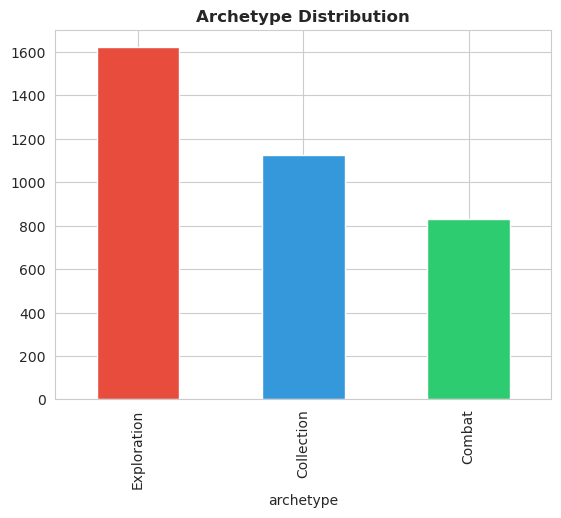

In [15]:
# 1. Action Archetype Distribution
plt.figure()
df['archetype'].value_counts().plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Archetype Distribution', fontweight='bold')
plt.savefig(os.path.join(VIZ_DIR, 'viz_archetype_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

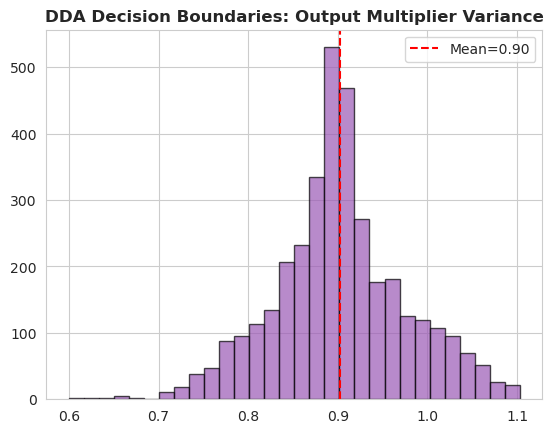

In [16]:
# 2. Target Response Curve
plt.figure()
plt.hist(df['target_multiplier'], bins=30, color='#9b59b6', alpha=0.7, edgecolor='black')
plt.axvline(df['target_multiplier'].mean(), color='red', linestyle='--', label=f'Mean={df["target_multiplier"].mean():.2f}')
plt.title('DDA Decision Boundaries: Output Multiplier Variance', fontweight='bold')
plt.legend()
plt.savefig(os.path.join(VIZ_DIR, 'viz_target_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

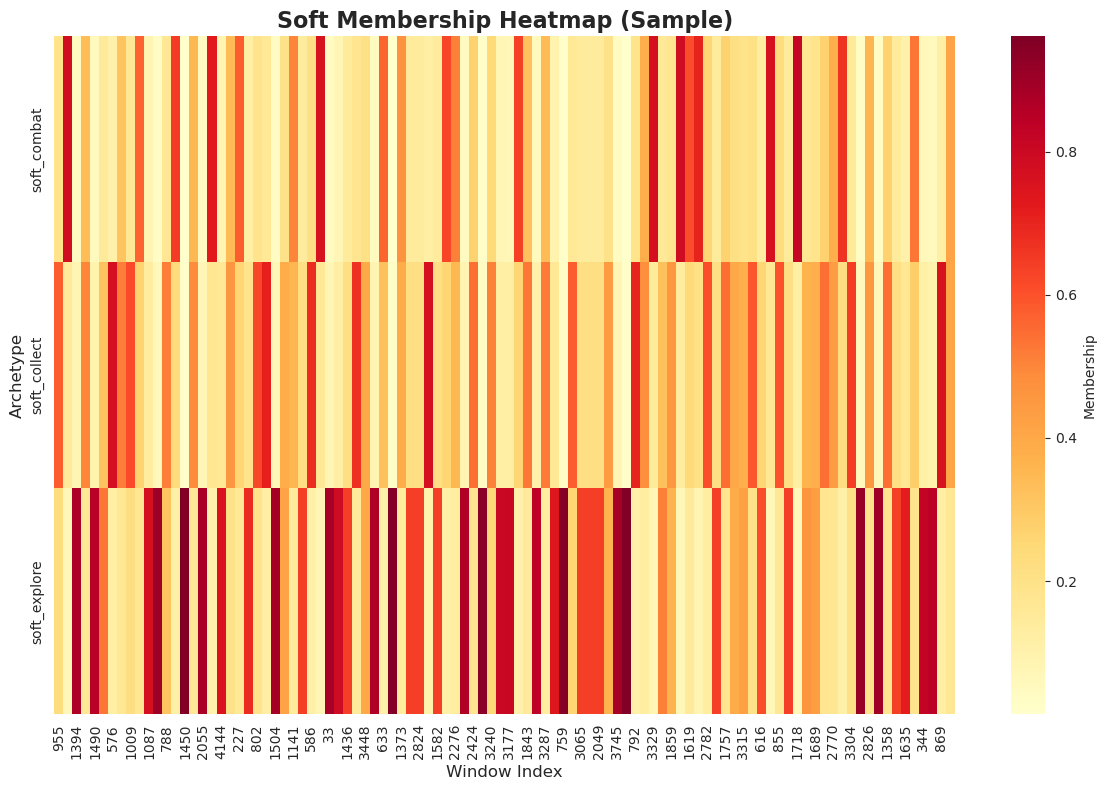

Saved viz_soft_membership_heatmap.png


In [17]:
# 3. Soft Membership Heatmap
soft_cols = ['soft_combat', 'soft_collect', 'soft_explore']
sample_size = min(100, len(df))
df_sample = df[soft_cols].sample(sample_size, random_state=42)

plt.figure(figsize=(12, 8))
sns.heatmap(df_sample.T, cmap='YlOrRd', cbar_kws={'label': 'Membership'})
plt.title('Soft Membership Heatmap (Sample)', fontsize=16, fontweight='bold')
plt.xlabel('Window Index', fontsize=12)
plt.ylabel('Archetype', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'viz_soft_membership_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved viz_soft_membership_heatmap.png")

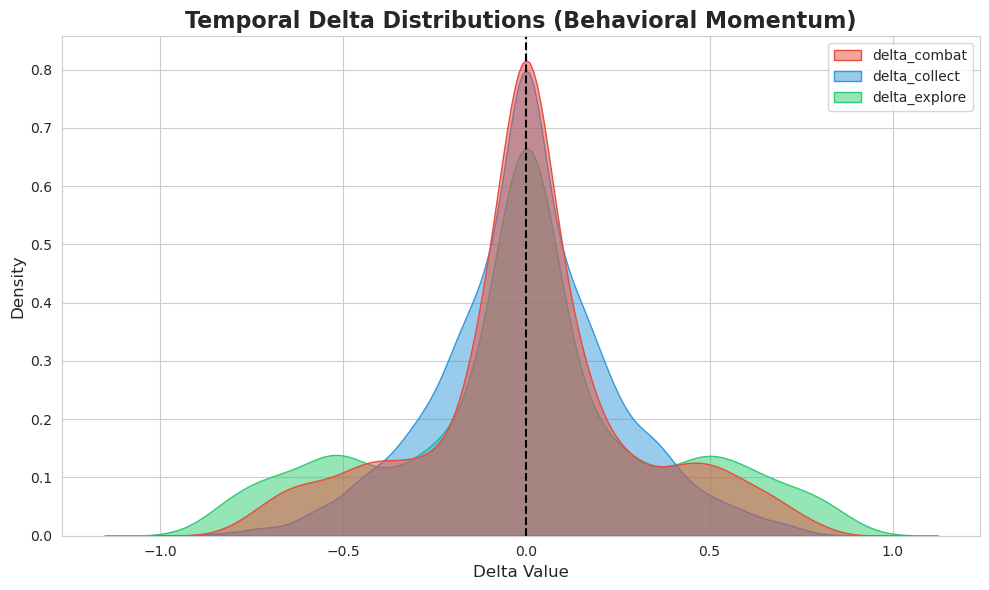

Saved viz_delta_distributions.png


In [18]:
# 4. Temporal Delta Distributions
delta_cols = ['delta_combat', 'delta_collect', 'delta_explore']
plt.figure(figsize=(10, 6))
# Using fill=True instead of shade=True for newer seaborn versions
sns.kdeplot(data=df[delta_cols], fill=True, alpha=0.5, palette=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Temporal Delta Distributions (Behavioral Momentum)', fontsize=16, fontweight='bold')
plt.xlabel('Delta Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'viz_delta_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved viz_delta_distributions.png")

### Model Surrogate Test Evaluation & Edge Cases

The Goal: Subject the trained Neural Network to extreme, ridiculous scenarios.

Before we let this AI dictate the difficulty of a live video game, we have to try to break it. What if a player literally just stands perfectly still staring at a wall (All-Zeros)? The game shouldn't crash, and the difficulty shouldn't drop into negative numbers.

We run mathematical edge cases here, verifying bounds, mapping residual scatter plots (Actual vs Predicted), and running Resampled Bootstrapping to prove our model is statistically sound and safe to deploy.

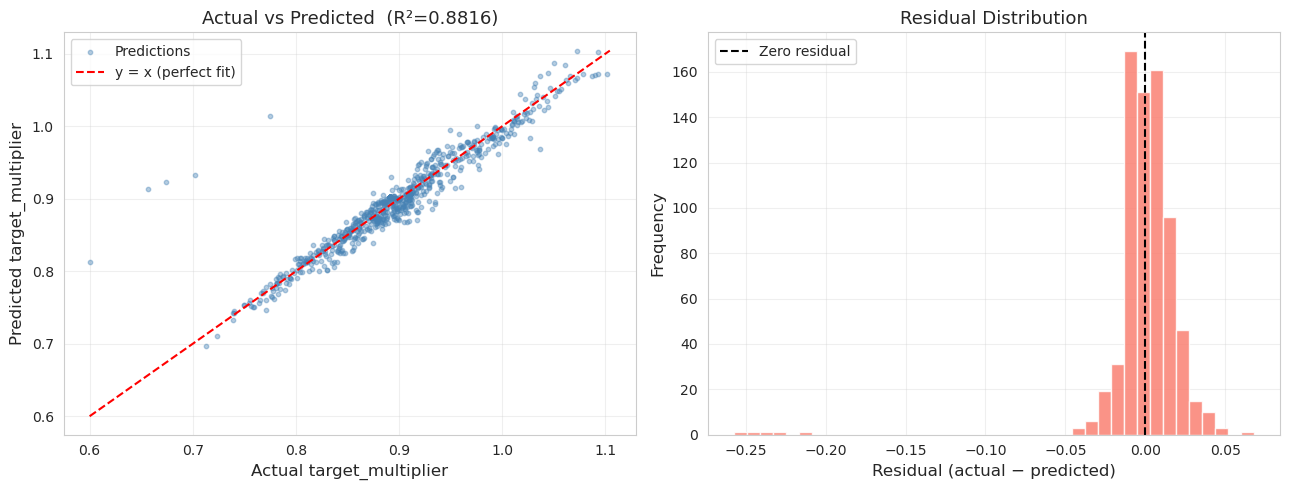

Plot saved to: /home/santiagodp/Documents/ML/AURA_players-analysis/visualizations/09_residual_analysis.png

Predictions within ±0.02 of actual: 85.8%


In [19]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred, alpha=0.4, s=10, c='steelblue', label='Predictions')
lo = min(y_test.min(), y_test_pred.min())
hi = max(y_test.max(), y_test_pred.max())
ax1.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='y = x (perfect fit)')
ax1.set_xlabel('Actual target_multiplier', fontsize=12)
ax1.set_ylabel('Predicted target_multiplier', fontsize=12)
ax1.set_title(f'Actual vs Predicted  (R²={r2_score(y_test, y_test_pred):.4f})', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residual Distribution
ax2 = axes[1]
ax2.hist(residuals, bins=40, color='salmon', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero residual')
ax2.set_xlabel('Residual (actual − predicted)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, '09_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to: {os.path.join(VIZ_DIR, "09_residual_analysis.png")}')

within_02 = np.mean(np.abs(residuals) <= 0.02) * 100
print(f'\nPredictions within ±0.02 of actual: {within_02:.1f}%')

In [20]:
def predict_single(x_list: list) -> float:
    """Helper: predict for a single 6-element input vector."""
    x = np.array(x_list, dtype=float).reshape(1, -1)
    return float(model.predict(x)[0])

print('Edge Case Tests')
print('=' * 60)

# Case 1: All-zero input — model should not crash; prediction should be >= 0.6 (clamp floor)
p1 = predict_single([0, 0, 0, 0, 0, 0])
print(f"Case 1 — All-zero input:        prediction = {p1:.6f}")
assert p1 >= 0.6, f'FAIL: all-zero prediction {p1:.6f} < 0.6'
print('  ✔ prediction >= 0.6')

# Case 2: Neutral state — soft memberships ~equal, deltas=0
p2 = predict_single([0.33, 0.33, 0.33, 0, 0, 0])
print(f"\nCase 2 — Neutral state:          prediction = {p2:.6f}")
assert 0.6 <= p2 <= 1.4, f'FAIL: neutral prediction {p2:.6f} outside [0.6, 1.4]'
print('  ✔ prediction in [0.6, 1.4]')

# Case 3: First window — all deltas = 0, equal soft membership
p3 = predict_single([0.33, 0.33, 0.33, 0, 0, 0])
print(f"\nCase 3 — First window (delta=0): prediction = {p3:.6f}")
assert abs(p3 - p2) < 1e-9, 'FAIL: first-window should equal neutral (same input)'
print('  ✔ same as neutral soft membership')

# Case 4: Extreme combat — high combat soft membership, strong delta
p4 = predict_single([1, 0, 0, 0.9, 0, 0])
print(f"\nCase 4 — Extreme combat:         prediction = {p4:.6f}")
assert 0.6 <= p4 <= 1.4, f'FAIL: extreme_combat prediction {p4:.6f} outside [0.6, 1.4]'
print('  ✔ prediction in [0.6, 1.4]')

print('\n✅ All edge case tests PASSED.')

Edge Case Tests
Case 1 — All-zero input:        prediction = 0.867305
  ✔ prediction >= 0.6

Case 2 — Neutral state:          prediction = 0.933019
  ✔ prediction in [0.6, 1.4]

Case 3 — First window (delta=0): prediction = 0.933019
  ✔ same as neutral soft membership

Case 4 — Extreme combat:         prediction = 1.132984
  ✔ prediction in [0.6, 1.4]

✅ All edge case tests PASSED.


In [21]:
N_BOOTSTRAP = 100
rng = np.random.default_rng(seed=42)
n_test = len(y_test)

boot_r2 = []
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n_test, size=n_test)
    y_b = y_test[idx]
    yp_b = y_test_pred[idx]
    boot_r2.append(r2_score(y_b, yp_b))

boot_r2 = np.array(boot_r2)
mean_r2 = boot_r2.mean()
std_r2  = boot_r2.std()
ci_lo   = np.percentile(boot_r2, 2.5)
ci_hi   = np.percentile(boot_r2, 97.5)

print('Bootstrap Confidence Interval (100 iterations)')
print('=' * 50)
print(f'  Mean R²  : {mean_r2:.6f}')
print(f'  Std  R²  : {std_r2:.6f}')
print(f'  95% CI   : [{ci_lo:.6f}, {ci_hi:.6f}]')

stored_r2 = r2_score(y_test, y_test_pred)
assert ci_lo <= stored_r2 <= ci_hi, 'WARN: stored R² outside 95% CI'
print(f'\n✔ Model R²={stored_r2:.6f} lies within the 95% bootstrap CI')
print('✅ Bootstrap analysis complete.')

Bootstrap Confidence Interval (100 iterations)
  Mean R²  : 0.880982
  Std  R²  : 0.032012
  95% CI   : [0.824264, 0.934259]

✔ Model R²=0.881597 lies within the 95% bootstrap CI
✅ Bootstrap analysis complete.


### Pipeline Integration Sanity Checks

The Goal: An automated safety net for future dataset updates.

Why we do this: If AURA enters a "Phase 3" beta testing round with 50,000 new players and we upload new raw data here, how do we know the pipeline didn't subtly break? These absolute Sanity Checks ensure that no mathematically impossible NaN values leaked into the training matrix, target variables remained bounded between 0.0 and 2.0, and fuzzy memberships sum perfectly to 100%.

In [22]:
print('Pipeline Integration Sanity Checks')
print('=' * 60)

import scipy.stats as scipy_stats

def report(step: int, name: str, passed: bool, actual_str: str):
    status = 'PASS ✅' if passed else 'FAIL ❌'
    print(f'  Step {step}: [{status}]  {name}  →  {actual_str}')

# Check 1: No NaNs in training matrix X
nan_count = np.isnan(X_test).sum()
p1 = (nan_count == 0)
report(1, 'No NaN in feature matrix X', p1, f'NaN count = {nan_count}')

# Check 2: Target bounds (0, 2)
y_min, y_max = float(y_test.min()), float(y_test.max())
y_finite = bool(np.all(np.isfinite(y_test)))
p2 = y_finite and (y_min > 0.0) and (y_max < 2.0)
report(2, 'Target multiplier in valid range (0, 2)', p2, f'min={y_min:.4f}, max={y_max:.4f}')

# Check 3: MLP output bounds
all_preds = model.predict(X_test)
p_min, p_max = float(all_preds.min()), float(all_preds.max())
p_finite = bool(np.all(np.isfinite(all_preds)))
p3 = p_finite and (p_min > 0.0) and (p_max < 2.0)
report(3, 'MLP predictions in range (0, 2)', p3, f'min={p_min:.4f}, max={p_max:.4f}')

# Check 4: Pearson correlation of delta_explore to target
delta_explore = df['delta_explore'].values
r_val, p_val = scipy_stats.pearsonr(df['delta_explore'].values, df['target_multiplier'].values)
p4 = abs(r_val) >= 0.5
report(4, '|Pearson r(delta_explore, target)| >= 0.5', p4, f'|r|={abs(r_val):.4f}')

# Check 5: Soft membership row sums = 1
soft_matrix = df[['soft_combat', 'soft_collect', 'soft_explore']].values
row_sums = soft_matrix.sum(axis=1)
max_dev = np.abs(row_sums - 1.0).max()
p5 = (max_dev < 1e-6)
report(5, 'Soft membership sums = 1', p5, f'max dev = {max_dev:.2e}')

print('=' * 60)
overall = '✅ ALL SANITY CHECKS PASSED' if all([p1, p2, p3, p4, p5]) else '❌ SOME CHECKS FAILED'
print(f'Overall Status: {overall}')

Pipeline Integration Sanity Checks
  Step 1: [PASS ✅]  No NaN in feature matrix X  →  NaN count = 0
  Step 2: [PASS ✅]  Target multiplier in valid range (0, 2)  →  min=0.6000, max=1.1018
  Step 3: [PASS ✅]  MLP predictions in range (0, 2)  →  min=0.6974, max=1.1043
  Step 4: [PASS ✅]  |Pearson r(delta_explore, target)| >= 0.5  →  |r|=0.8366
  Step 5: [PASS ✅]  Soft membership sums = 1  →  max dev = 2.22e-16
Overall Status: ✅ ALL SANITY CHECKS PASSED
